In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Le modèle XGBoost
import xgboost as xgb

print(f"Version de XGBoost : {xgb.__version__}")

Version de XGBoost : 3.2.0


## Récupération des données

In [2]:
print("Chargement des données en cours...")
start_time = time.time()

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# Pour y, on s'assure d'avoir un vecteur plat (1D)
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

load_time = time.time() - start_time
print(f"Données chargées en {load_time:.2f} secondes.")
print(f"Dimensions Train : {X_train.shape} | Dimensions Test : {X_test.shape}")

Chargement des données en cours...
Données chargées en 7.86 secondes.
Dimensions Train : (3712444, 13) | Dimensions Test : (928111, 13)


## Stratégie d'entraînement


In [3]:
# Configuration du modèle
# On utilise 'hist' pour la rapidité sur de gros volumes
# 'n_jobs=-1' utilise tous les CPU
xgb_model = xgb.XGBRegressor(
    n_estimators=500,        # Plus d'arbres, mais plus courts
    max_depth=8,             # Profondeur modérée pour éviter l'overfitting
    learning_rate=0.1,       # Pas d'apprentissage (vitesse de correction)
    tree_method='hist',      # Algorithme optimisé pour gros datasets
    n_jobs=-1,
    random_state=42,
    objective='reg:squarederror'
)

print("Début de l'entraînement XGBoost...")
start_time = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # On surveille l'erreur sur le test en temps réel
    verbose=50                   # Affiche l'évolution tous les 50 arbres
)

end_time = time.time() - start_time
print(f"Entraînement terminé en {end_time/60:.2f} minutes.")

Début de l'entraînement XGBoost...
[0]	validation_0-rmse:232265.97853
[50]	validation_0-rmse:129972.62256
[100]	validation_0-rmse:128157.92524
[150]	validation_0-rmse:126821.62218
[200]	validation_0-rmse:126093.60263
[250]	validation_0-rmse:125702.31155
[300]	validation_0-rmse:125433.35248
[350]	validation_0-rmse:125122.22465
[400]	validation_0-rmse:124918.76958
[450]	validation_0-rmse:124789.39962
[499]	validation_0-rmse:124681.03368
Entraînement terminé en 2.78 minutes.


##  Prédictions et Métriques de performance

In [4]:
# Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# Métriques
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("-" * 30)
print(f"RÉSULTATS XGBOOST")
print("-" * 30)
print(f"R² Score : {r2_xgb:.4f}")
print(f"MAE      : {mae_xgb:.2f} €")
print(f"RMSE     : {rmse_xgb:.2f} €")
print("-" * 30)

------------------------------
RÉSULTATS XGBOOST
------------------------------
R² Score : 0.7491
MAE      : 59829.96 €
RMSE     : 124681.03 €
------------------------------


## Analyse de l'importance des variables (Feature Importance)

<Figure size 1000x600 with 0 Axes>

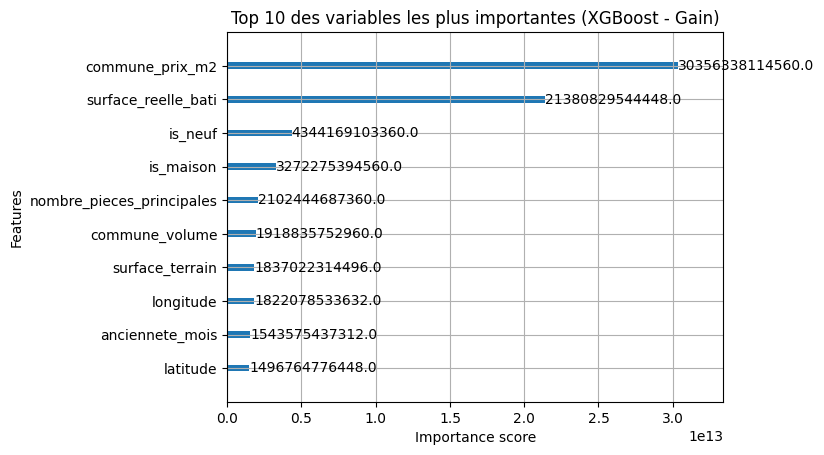

In [5]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.title('Top 10 des variables les plus importantes (XGBoost - Gain)')
plt.show()